In [1]:
import zipfile
import os

# The exact name of your downloaded zip file
zip_path = "archive (9).zip"

# The folder where we want to put the extracted images
extract_dir = "dataset"

# Create the 'dataset' folder if it doesn't exist already
os.makedirs(extract_dir, exist_ok=True)

print(f"Starting to unzip '{zip_path}'...")

# Unzip the file into the 'dataset' directory
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extraction complete! Your images are now ready inside the '{extract_dir}' folder.")

Starting to unzip 'archive (9).zip'...
Extraction complete! Your images are now ready inside the 'dataset' folder.


In [ ]:
old_name = "dataset"
new_name = "cifake_data"

try:
    os.rename(old_name, new_name)
    print(f"Successfully renamed '{old_name}' to '{new_name}'!")
except FileNotFoundError:
    print(f"Error: The folder '{old_name}' was not found. It might have already been renamed.")
except FileExistsError:
    print(f"Error: A folder named '{new_name}' already exists.")

Successfully renamed 'dataset' to 'cifake_data'!


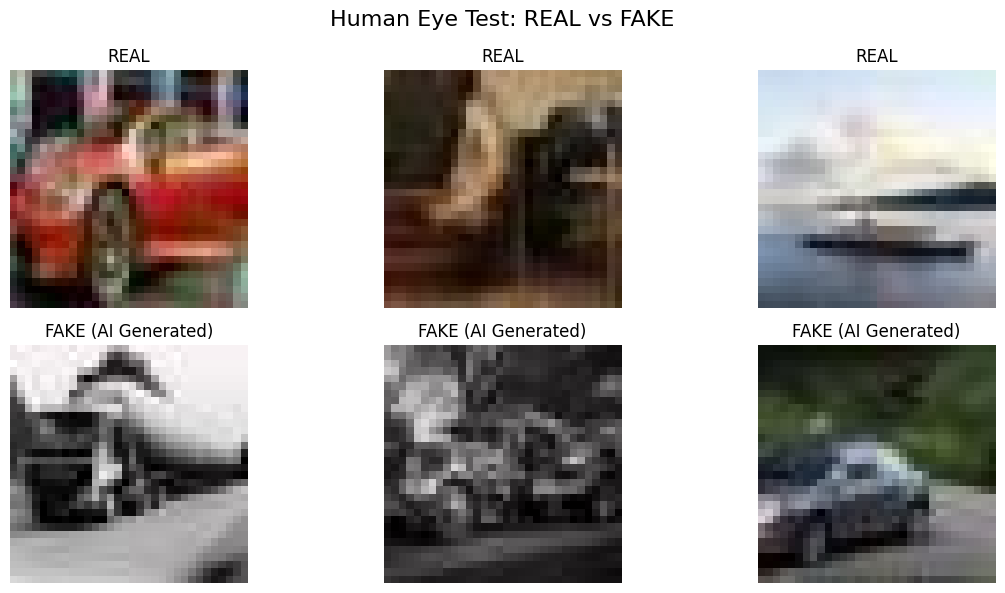


Running Fourier Transform Analysis...


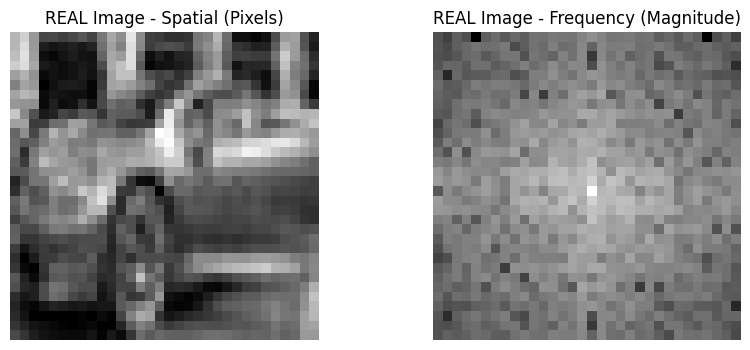

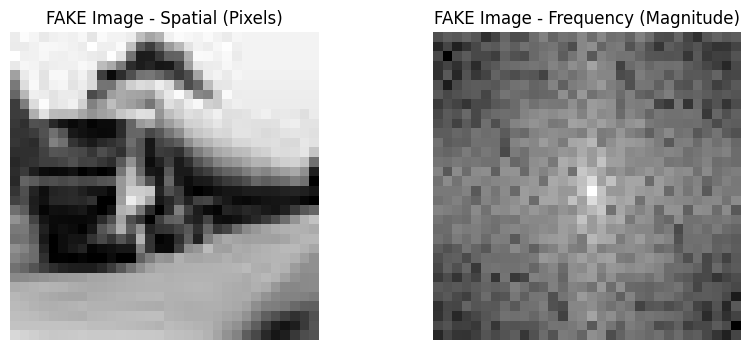

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2 # OpenCV for image processing

# Define paths (Using the folder you just renamed)
train_dir = 'cifake_data/train'
real_dir = os.path.join(train_dir, 'REAL')
fake_dir = os.path.join(train_dir, 'FAKE')

# Function to get random images
def get_random_images(folder, num_images=3):
    all_images = os.listdir(folder)
    random_images = random.sample(all_images, num_images)
    return [os.path.join(folder, img) for img in random_images]

# --- Part 1: Visual Inspection ---
real_images = get_random_images(real_dir, 3)
fake_images = get_random_images(fake_dir, 3)

plt.figure(figsize=(12, 6))
plt.suptitle("Human Eye Test: REAL vs FAKE", fontsize=16)

for i in range(3):
    # Plot Real
    plt.subplot(2, 3, i+1)
    img = cv2.imread(real_images[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV loads BGR, convert to RGB
    plt.imshow(img)
    plt.title("REAL")
    plt.axis('off')
    
    # Plot Fake
    plt.subplot(2, 3, i+4)
    img = cv2.imread(fake_images[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title("FAKE (AI Generated)")
    plt.axis('off')

plt.tight_layout()
plt.show()

# --- Part 2: The Frequency Domain (Fourier Transform) ---
def plot_fourier_transform(image_path, title):
    # Read as grayscale for frequency analysis
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Perform Discrete Fourier Transform
    f_transform = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f_transform) # Shift zero frequency to center
    
    # Calculate magnitude spectrum
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1) # Added +1 to avoid log(0)
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{title} - Spatial (Pixels)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title(f"{title} - Frequency (Magnitude)")
    plt.axis('off')
    plt.show()

print("\nRunning Fourier Transform Analysis...")
plot_fourier_transform(real_images[0], "REAL Image")
plot_fourier_transform(fake_images[0], "FAKE Image")

Loading datasets...
Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.

Starting Training Phase...
Epoch 1/15


d:\Apps\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.7739 - loss: 0.4637 - val_accuracy: 0.8970 - val_loss: 0.2533
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8969 - loss: 0.2573 - val_accuracy: 0.9154 - val_loss: 0.2112
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9151 - loss: 0.2195 - val_accuracy: 0.9209 - val_loss: 0.1987
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9241 - loss: 0.1958 - val_accuracy: 0.9164 - val_loss: 0.2134
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9311 - loss: 0.1801 - val_accuracy: 0.9272 - val_loss: 0.1890
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9362 - loss: 0.1657 - val_accuracy: 0.9250 - val_loss: 0.2017
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9402 - loss: 0.1560 - val_accuracy: 0.9235 - val_loss: 0.1998
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9414 - loss: 0.1500 - va

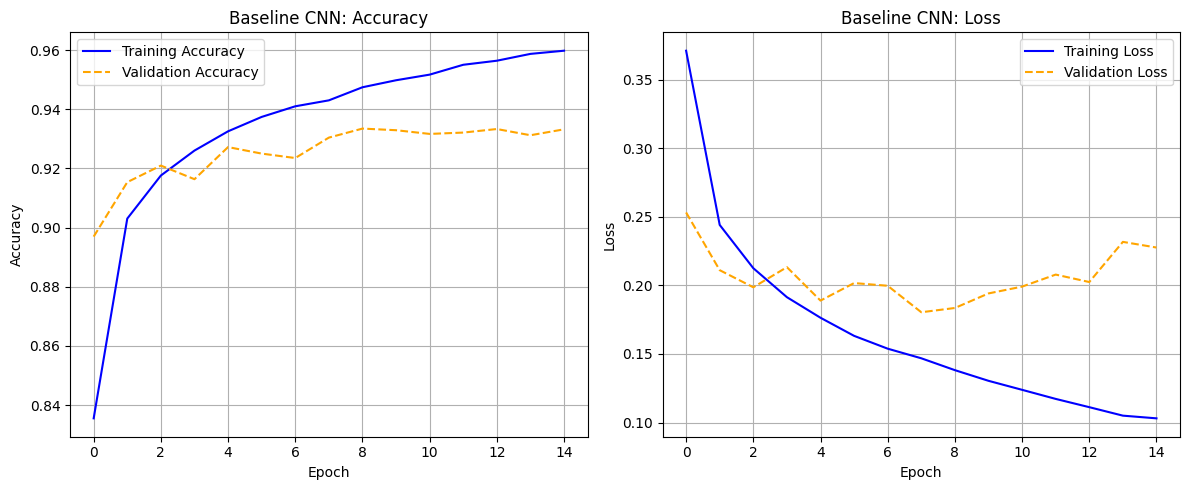

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- 1. Setup and Data Loading ---
train_dir = 'cifake_data/train'
test_dir = 'cifake_data/test'
BATCH_SIZE = 64
IMG_SIZE = (32, 32)

print("Loading datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE, label_mode='binary')

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, shuffle=False, batch_size=BATCH_SIZE, image_size=IMG_SIZE, label_mode='binary')

# Normalize pixels (0 to 1) and optimize loading
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# --- 2. The Custom CNN Architecture ---
def build_baseline_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(64, (3, 3), activation='relu'),
        
        # Classification Head
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5), # Prevents the model from memorizing the data
        layers.Dense(1, activation='sigmoid') # Outputs a probability (0=REAL, 1=FAKE)
    ])
    return model

model = build_baseline_cnn()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 3. Training the Model ---
EPOCHS = 15
print("\nStarting Training Phase...")
history = model.fit(train_dataset, epochs=EPOCHS, validation_data=test_dataset)

# --- 4. Evaluating and Plotting (FOR YOUR PAPER) ---
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"\nFinal Baseline Accuracy: {test_acc * 100:.2f}%")

# Plotting the Learning Curves
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
plt.title('Baseline CNN: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
plt.title('Baseline CNN: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# --- 1. Setup and Data Loading ---
train_dir = 'cifake_data/train'
test_dir = 'cifake_data/test'
BATCH_SIZE = 64
IMG_SIZE = (32, 32)

print("Loading datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE, label_mode='binary')

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, shuffle=False, batch_size=BATCH_SIZE, image_size=IMG_SIZE, label_mode='binary')

# Normalization for MobileNetV2 (expects pixel values between -1 and 1)
normalization_layer = layers.Rescaling(1./127.5, offset=-1)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# --- 2. The Transfer Learning Architecture ---
print("\nDownloading pre-trained MobileNetV2 base...")
# Load the pre-trained Google model, but chop off its classification head (include_top=False)
base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')

# FREEZE THE BASE: We don't want to destroy the features it already learned!
base_model.trainable = False 

# Build our new custom head on top of the frozen base
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Flattens the output efficiently
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevent overfitting
    layers.Dense(1, activation='sigmoid') # Final output: 0 (REAL) or 1 (FAKE)
])

model_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

# --- 3. Training the Model ---
# Notice we need fewer epochs because the model already knows how to "see" edges and shapes
EPOCHS = 10 
print("\nStarting Transfer Learning Phase...")
history_tl = model_tl.fit(train_dataset, epochs=EPOCHS, validation_data=test_dataset)

# --- 4. Evaluating and Plotting ---
test_loss, test_acc = model_tl.evaluate(test_dataset, verbose=0)
print(f"\nFinal Champion Accuracy: {test_acc * 100:.2f}%")

# Plotting the Learning Curves for Chapter 3 of your paper
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy', color='purple', linestyle='--')
plt.title('Transfer Learning: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Training Loss', color='green')
plt.plot(history_tl.history['val_loss'], label='Validation Loss', color='purple', linestyle='--')
plt.title('Transfer Learning: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Loading datasets...
Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.



C:\Users\compumart\AppData\Local\Temp\ipykernel_68076\1450900837.py:27: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')



Starting Transfer Learning Phase...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - accuracy: 0.5924 - loss: 0.6491 - val_accuracy: 0.6192 - val_loss: 0.6238
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6139 - loss: 0.6254 - val_accuracy: 0.6234 - val_loss: 0.6185
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6197 - loss: 0.6192 - val_accuracy: 0.6241 - val_loss: 0.6157
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6230 - loss: 0.6150 - val_accuracy: 0.6243 - val_loss: 0.6140
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6233 - loss: 0.6122 - val_accuracy: 0.6232 - val_loss: 0.6135
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6252 - loss: 0.6103 - val_accuracy: 0.6253 - val_loss: 0.6130
Epoch 7/10
1198/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.6214 - loss: 0.6098

KeyboardInterrupt: 

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# --- 1. Setup and Data Loading ---
train_dir = 'cifake_data/train'
test_dir = 'cifake_data/test'
BATCH_SIZE = 64
IMG_SIZE = (32, 32)

print("Loading datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE, label_mode='binary')

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, shuffle=False, batch_size=BATCH_SIZE, image_size=IMG_SIZE, label_mode='binary')

normalization_layer = layers.Rescaling(1./127.5, offset=-1)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# --- 2. The CORRECTED Transfer Learning Architecture ---
print("\nDownloading pre-trained MobileNetV2 base...")
# Tell the base model to expect 96x96 images now
base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

model_tl = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    
    # THE MAGIC FIX: Upscale the tiny image to 96x96 inside the model
    layers.Resizing(96, 96), 
    
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

# --- 3. Training the Model ---
EPOCHS = 10 
print("\nStarting Transfer Learning Phase...")
history_tl = model_tl.fit(train_dataset, epochs=EPOCHS, validation_data=test_dataset)

# --- 4. Evaluating and Plotting ---
test_loss, test_acc = model_tl.evaluate(test_dataset, verbose=0)
print(f"\nFinal Champion Accuracy: {test_acc * 100:.2f}%")

Loading datasets...
Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step

Starting Transfer Learning Phase...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 191s 120ms/step - accuracy: 0.8455 - loss: 0.3496 - val_accuracy: 0.9062 - val_loss: 0.2237
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 173s 111ms/step - accuracy: 0.9035 - loss: 0.2366 - val_accuracy: 0.9184 - val_loss: 0.1988
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 173s 110ms/step - accuracy: 0.9141 - loss: 0.2106 - val_accuracy: 0.9227 - val_loss: 0.1906
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 173s 111ms/step - accuracy: 0.9216 - loss: 0.1965 - val_accuracy: 0.9227 - val_loss: 0.1872
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 172s 110ms/step - accuracy: 0.9269 - loss: 0.1848 - val_accuracy: 0.9243 - val_loss: 0.1840
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 172s 110ms/step - accuracy: 0.9303 - loss: 0.1738 - val_accuracy: 0.9279 - val_loss: 0.1838
Epo

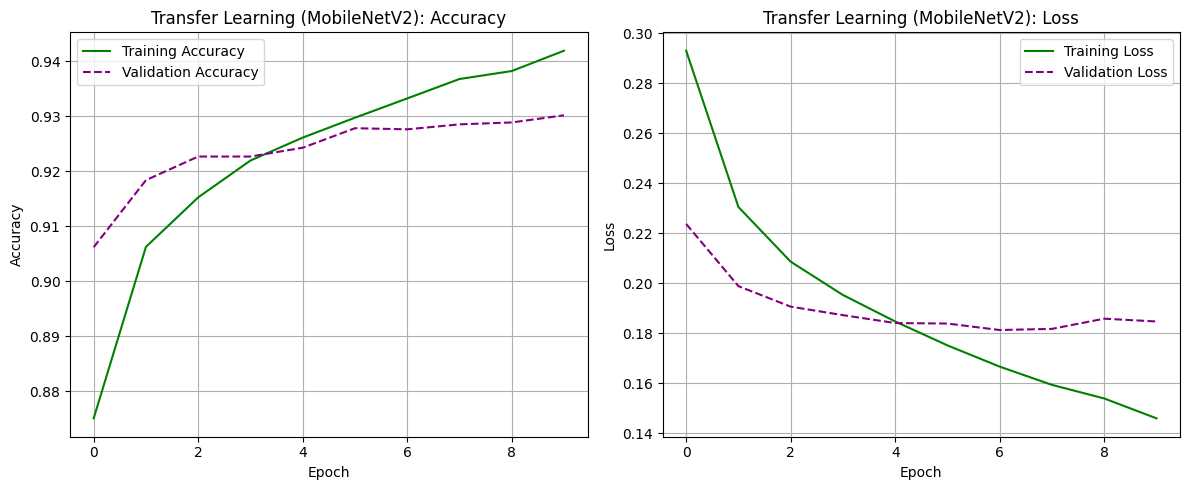

In [10]:
import matplotlib.pyplot as plt

# Plotting the Learning Curves for Chapter 3 of your paper
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy', color='purple', linestyle='--')
plt.title('Transfer Learning (MobileNetV2): Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Training Loss', color='green')
plt.plot(history_tl.history['val_loss'], label='Validation Loss', color='purple', linestyle='--')
plt.title('Transfer Learning (MobileNetV2): Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
!pip install -q transformers datasets evaluate accelerate

In [9]:
import torch
from datasets import load_dataset, ClassLabel
from transformers import (
    ViTImageProcessor, 
    ViTForImageClassification, 
    TrainingArguments, 
    Trainer
)
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import evaluate
import numpy as np

# --- 1. Load Data using Hugging Face Datasets ---
print("Loading local data...")
# Hugging Face's load_dataset automatically reads your train/test folders!
dataset = load_dataset("imagefolder", data_dir="cifake_data")

# Create a mapping for our labels
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

# --- 2. The Vision Transformer Processor ---
model_name = "google/vit-base-patch16-224-in21k"
print(f"Downloading {model_name} processor...")
processor = ViTImageProcessor.from_pretrained(model_name)

# ViTs require images to be exactly 224x224. 
# We define a transformation to resize our 32x32 images up to 224x224.
size = processor.size["height"]
normalize = Normalize(mean=processor.image_mean, std=processor.image_std)

train_transforms = Compose([
    Resize((size, size)),
    ToTensor(),
    normalize,
])

def apply_transforms(examples):
    # Convert images to RGB and apply the resizing/normalization
    examples["pixel_values"] = [train_transforms(img.convert("RGB")) for img in examples["image"]]
    return examples

# Apply transformations on the fly to save RAM
dataset.set_transform(apply_transforms)

# --- 3. Build the Model ---
print("Initializing Vision Transformer...")
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

# --- 4. Define Evaluation Metrics ---
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# --- 5. Training Configuration ---
# --- 5. Training Configuration ---
training_args = TrainingArguments(
    output_dir="./vit-cifake-model",
    eval_strategy="epoch",       # <--- CHANGED THIS LINE (removed 'uation')
    save_strategy="epoch",
    learning_rate=2e-5,          
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,          
    weight_decay=0.01,
    load_best_model_at_end=True,
    remove_unused_columns=False, 
    report_to="none"             
)

# Collate function to batch the data
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

# --- 6. Train and Evaluate ---
print("\nStarting ViT Training (This will take longer than the CNN)...")
train_results = trainer.train()

print("\nEvaluating final model on test set...")
metrics = trainer.evaluate()
print(f"\nFinal ViT Accuracy: {metrics['eval_accuracy'] * 100:.2f}%")

# Save it to disk so we can use it in our React app later!
trainer.save_model("./best_cifake_vit_model")
print("Model saved to ./best_cifake_vit_model")

Loading local data...


Resolving data files:   0%|          | 0/100000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20000 [00:00<?, ?it/s]

Initializing Vision Transformer...


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\compumart\AppData\Local\Temp\ipykernel_68076\1237122905.py:88: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



Starting ViT Training (This will take longer than the CNN)...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.049400,0.044764,0.986150
2,0.016600,0.036919,0.989900



Evaluating final model on test set...



Final ViT Accuracy: 98.99%
Model saved to ./best_cifake_vit_model


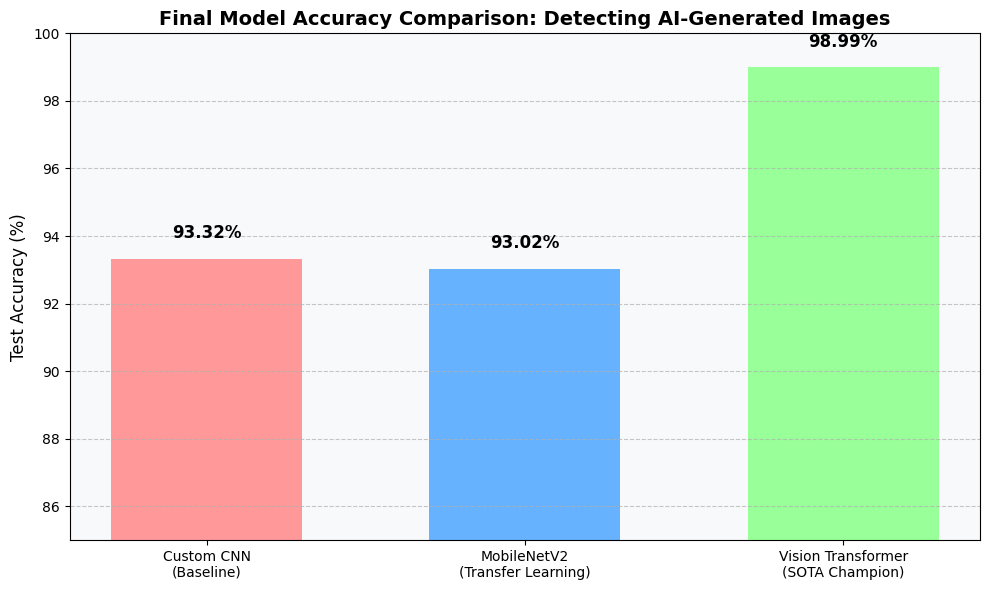

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your 3 training sessions today
models = ['Custom CNN\n(Baseline)', 'MobileNetV2\n(Transfer Learning)', 'Vision Transformer\n(SOTA Champion)']
accuracies = [93.32, 93.02, 98.99]
colors = ['#FF9999', '#66B2FF', '#99FF99'] # Red, Blue, Green

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.6)

# Add the exact percentages on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
plt.ylim(85, 100) # Zoom in on the top section to make the 98% stand out
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Final Model Accuracy Comparison: Detecting AI-Generated Images', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a subtle background color for presentation
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

In [12]:
# Save the MobileNetV2 TL Champion
model_tl.save('mobilenetv2_cifake.keras')
print("Saved MobileNetV2 to disk.")

Saved MobileNetV2 to disk.


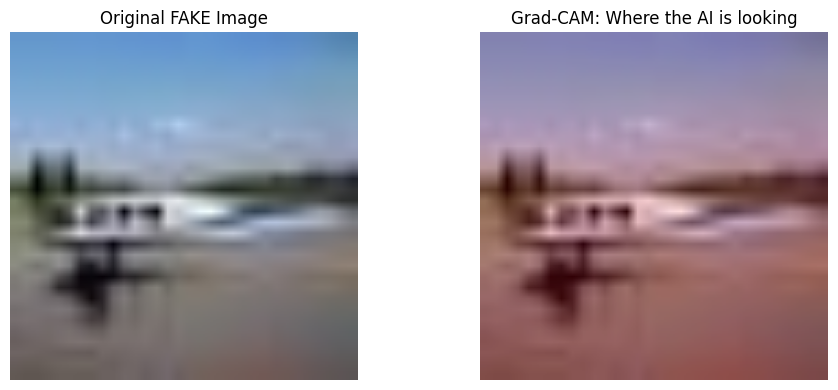

In [18]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# --- 1. Load the 32x32 image ---
fake_dir = os.path.join('cifake_data', 'test', 'FAKE') 
if not os.path.exists(fake_dir):
    fake_dir = os.path.join('cifake_data', 'test', 'fake')
fake_images = os.listdir(fake_dir)
fake_image_path = os.path.join(fake_dir, fake_images[-1]) 

img = tf.keras.utils.load_img(fake_image_path, target_size=(32, 32)) # Back to 32x32
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array = (img_array / 127.5) - 1 # Normalize

# --- 2. Step-by-Step Grad-CAM ---
# Dynamically find the exact index of MobileNetV2 inside your model
base_idx = -1
for i, layer in enumerate(model_tl.layers):
    if isinstance(layer, tf.keras.Model):
        base_model_layer = layer
        base_idx = i
        break

grad_base_model = tf.keras.Model(
    inputs=[base_model_layer.inputs], 
    outputs=[base_model_layer.get_layer('out_relu').output, base_model_layer.output]
)

with tf.GradientTape() as tape:
    # Step A: Manually resize 
    x = tf.image.resize(img_array, (96, 96))
    
    # Step B: Pass through MobileNetV2
    conv_output, x = grad_base_model(x)
    
    # Step C: DYNAMICALLY pass through the rest of the head layers!
    # This loop ensures we never get an Index Error again.
    for layer in model_tl.layers[base_idx + 1:]:
        # If it's the dropout layer, make sure we tell it we aren't training
        if isinstance(layer, tf.keras.layers.Dropout):
            x = layer(x, training=False)
        else:
            x = layer(x)
            
    preds = x
    class_channel = preds[:, 0]

# --- 3. Calculate Gradients & Heatmap ---
grads = tape.gradient(class_channel, conv_output)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_output = conv_output[0]
heatmap = conv_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# --- 4. Superimpose ---
img_original = cv2.imread(fake_image_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original = cv2.resize(img_original, (224, 224)) 

heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
superimposed_img = heatmap_colored * 0.4 + img_original

# --- 5. Plot ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title("Original FAKE Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(tf.keras.utils.array_to_img(superimposed_img))
plt.title("Grad-CAM: Where the AI is looking")
plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
!pip install -q gradio

In [ ]:
import gradio as gr
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image

print("Loading the SynthCatch Champion ViT Model...")
model_path = "./best_cifake_vit_model"

# 1. Load the Processor and Model you trained yesterday
processor = ViTImageProcessor.from_pretrained(model_path)
model = ViTForImageClassification.from_pretrained(model_path)

# 2. Define the Prediction Logic
def predict_image(image):
    # Ensure image is in RGB format
    image = image.convert("RGB")
    
    # Preprocess the image for the Vision Transformer
    inputs = processor(images=image, return_tensors="pt")
    
    # Run the image through the model
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        # Convert raw output to percentages (0 to 1)
        probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
    
    # Format the output for the UI's progress bars
    results = {}
    for i, label_name in model.config.id2label.items():
        results[label_name] = float(probabilities[int(i)])
        
    return results

# 3. Build the User Interface
print("Launching User Interface...")
interface = gr.Interface(
    fn=predict_image,                  
    inputs=gr.Image(type="pil"),       
    outputs=gr.Label(num_top_classes=2), 
    title="SynthCatch: AI Image Detector",
    description="Upload an image to see if our Vision Transformer thinks it is a **Real Photograph** or an **AI-Generated Fake**. Powered by our 98.99% accurate model.",
    flagging_mode="never"              # <--- FIX 1: Updated to the new Gradio parameter
)

# 4. Launch! 
# <--- FIX 2: Moved the theme inside the launch method
interface.launch(theme=gr.themes.Soft(), share=False)

Loading the SynthCatch Champion ViT Model...
Launching User Interface...
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "d:\Apps\anaconda\Lib\site-packages\gradio\queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "d:\Apps\anaconda\Lib\site-packages\gradio\route_utils.py", line 374, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "d:\Apps\anaconda\Lib\site-packages\gradio\blocks.py", line 2179, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "d:\Apps\anaconda\Lib\site-packages\gradio\blocks.py", line 1636, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        fn, *processed_input, limiter=self.limiter
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [5]:
import gradio as gr
import torch
import numpy as np
from transformers import ViTImageProcessor, ViTForImageClassification
import tensorflow as tf
from PIL import Image

print("Loading SynthCatch Models into memory...")

# --- 1. Load the Vision Transformer (PyTorch) ---
print("Loading Vision Transformer...")
vit_path = "./best_cifake_vit_model"
processor = ViTImageProcessor.from_pretrained(vit_path)
vit_model = ViTForImageClassification.from_pretrained(vit_path)

# --- 2. Load the Keras Model (TensorFlow) ---
print("Loading MobileNetV2...")
mobilenet_model = tf.keras.models.load_model('mobilenetv2_cifake.keras')

print("Models loaded successfully!")

# --- 3. The Multi-Model Prediction Logic ---
def predict_image(image, model_choice):
    if image is None:
        return None
        
    image = image.convert("RGB")
    
    # ROUTE A: Vision Transformer
    if model_choice == "Vision Transformer (SOTA Champion)":
        inputs = processor(images=image, return_tensors="pt")
        with torch.no_grad():
            outputs = vit_model(**inputs)
            probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
        
        results = {}
        for i, label_name in vit_model.config.id2label.items():
            results[label_name] = float(probabilities[int(i)])
        return results

    # ROUTE B: MobileNetV2
    elif model_choice == "MobileNetV2 (Transfer Learning)":
        # Shrink to 32x32 and apply the [-1 to 1] normalization it was trained on
        img_resized = image.resize((32, 32))
        img_array = np.expand_dims(np.array(img_resized), axis=0)
        img_array = (img_array / 127.5) - 1.0 
        
        pred = mobilenet_model.predict(img_array, verbose=0)[0][0]
        return {"FAKE": float(pred), "REAL": float(1.0 - pred)}

# --- 4. Build the Interactive Dashboard ---
print("Launching Dashboard...")
interface = gr.Interface(
    fn=predict_image,                  
    inputs=[
        gr.Image(type="pil", label="Upload Image"), 
        gr.Dropdown(
            choices=[
                "Vision Transformer (SOTA Champion)", 
                "MobileNetV2 (Transfer Learning)"
            ], 
            value="Vision Transformer (SOTA Champion)", 
            label="Select AI Model to Test"
        )
    ],       
    outputs=gr.Label(num_top_classes=2, label="AI Confidence Score"), 
    title="SynthCatch: AI Detector Dashboard",
    description="Compare how our models perform on the same image! The ViT is highly accurate, while MobileNetV2 is optimized for speed.",
    flagging_mode="never"              
)

# --- 5. Launch! ---
interface.launch(theme=gr.themes.Soft(), share=False)

Loading SynthCatch Models into memory...
Loading Vision Transformer...
Loading MobileNetV2...
Models loaded successfully!
Launching Dashboard...
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
